In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from torch.utils.data import Dataset, DataLoader
from source.model.memory import MemoryContinuous

In [2]:
def generate_seq(total_samples, vocab=10):
    return torch.arange(total_samples)%vocab

In [3]:
class DatasetConverter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=3):
        self.X = torch.zeros((len(data)-working_memory-short_term_memory, short_term_memory), dtype=torch.int64)
        for i in range(self.X.shape[0]):
            for j in range(self.X.shape[1]):
                self.X[i, j] = data[i+j]

        self.X = torch.tensor(self.X).long()

    def __getitem__(self, idx):
        return self.X[idx]

    def __len__(self):
        return self.X.shape[0]

In [38]:
torch.manual_seed(0)
random.seed(0)

vocab_size = 10
seq_len = 3
hidden_size = 30
num_epochs = 20
total_samples = 1000

model = MemoryContinuous(
    input_size=vocab_size,
    hidden_size=hidden_size,
    embedding_dim=3,
    tau=.1
)

sequence = generate_seq(total_samples, vocab_size)
dataset = DatasetConverter(sequence)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

lambda_cont = 0.5   # continuity strength

h = None
h_prev = None   # store previous hidden state
for epoch in range(num_epochs):
    for x in loader:
        logits, h_ = model(x, h)

        # -------- reconstruction loss --------
        #print(logits[:, 2], x[:, seq_len-2-1])
        recon_loss = sum(
            criterion(logits[:, t], x[:, seq_len-t-1]) for t in range(seq_len)
        ) / seq_len

        # -------- continuity regularizer --------
        if h_prev is None:
            cont_loss = torch.tensor(0.0, device=logits.device)
        else:
            cont_loss = torch.mean((h_ - h_prev) ** 2)

        loss = recon_loss + lambda_cont * cont_loss

        if loss > 1e-4:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # update hidden states
        h_prev = h_.detach()
        h = h_.detach()

    print(
        f"Epoch {epoch}: "
        f"recon={recon_loss.item():.4f}, "
        f"cont={cont_loss.item():.4f}"
    )


/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_47888/4104037018.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.X).long()


Epoch 0: recon=0.0431, cont=0.1875
Epoch 1: recon=0.0147, cont=0.1112
Epoch 2: recon=0.0086, cont=0.0690
Epoch 3: recon=0.0057, cont=0.0448
Epoch 4: recon=0.0036, cont=0.0320
Epoch 5: recon=0.0026, cont=0.0256
Epoch 6: recon=0.0019, cont=0.0189
Epoch 7: recon=0.0015, cont=0.0147
Epoch 8: recon=0.0010, cont=0.0114
Epoch 9: recon=0.0009, cont=0.0175
Epoch 10: recon=0.0009, cont=0.0144
Epoch 11: recon=0.0009, cont=0.0120
Epoch 12: recon=0.0008, cont=0.0104
Epoch 13: recon=0.0007, cont=0.0094
Epoch 14: recon=0.0005, cont=0.0192
Epoch 15: recon=0.0005, cont=0.0092
Epoch 16: recon=0.0005, cont=0.0082
Epoch 17: recon=0.0004, cont=0.0058
Epoch 18: recon=0.0002, cont=0.0082
Epoch 19: recon=0.0003, cont=0.0076


tensor([[0, 1, 2]])
tensor([[1, 2, 3]])
tensor([[2, 3, 4]])
tensor([[3, 4, 5]])
tensor([[4, 5, 6]])
tensor([[5, 6, 7]])
tensor([[6, 7, 8]])
tensor([[7, 8, 9]])
tensor([[8, 9, 0]])
tensor([[9, 0, 1]])
MDS stress: 1.8551897624521887


/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_47888/4104037018.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(self.X).long()


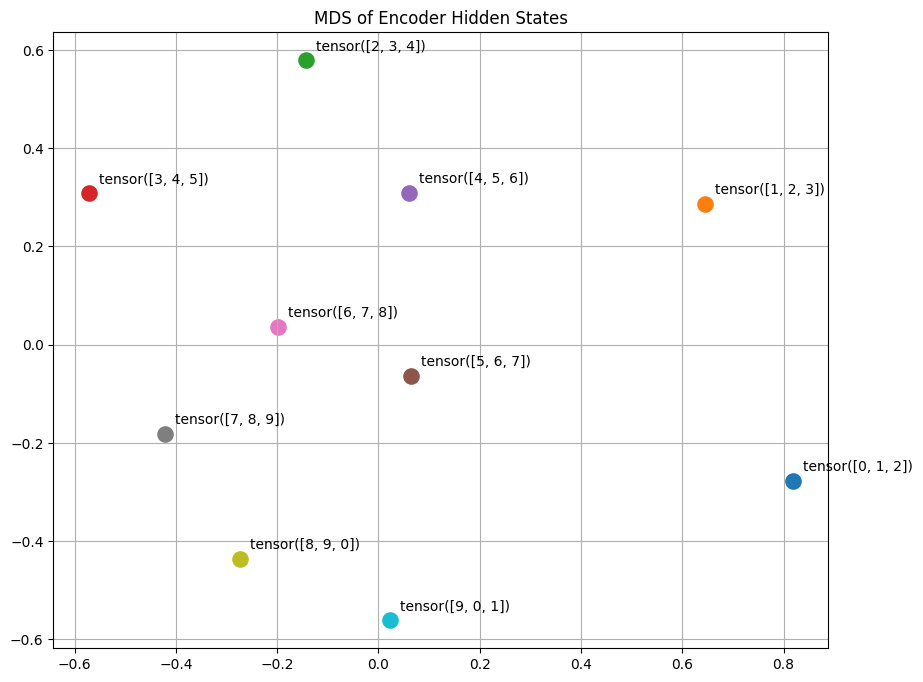

In [39]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import itertools

# Step 1: Generate the sequence
sequence = generate_seq(vocab_size+4, vocab_size)
dataset = DatasetConverter(sequence)
loader = DataLoader(dataset, batch_size=1, shuffle=False)
# Step 2–3: Run through encoder and collect hidden states
hidden_codes = []
labels = []

h = None
model.eval()
with torch.no_grad():
    for x in loader:
        print(x)
        _, h = model(x, h)
        hidden_codes.append(h[0].numpy())  # extract (H,) from (1,1,H)
        labels.append("".join(map(str, x)))

# Step 4: Reduce dimension
hidden_codes = torch.tensor(hidden_codes)
# Step 1: MDS projection
mds = MDS(
    n_components=2,
    random_state=420,
    dissimilarity="euclidean",  # uses Euclidean distances on hidden_codes
    normalized_stress="auto"
)

embeddings = mds.fit_transform(hidden_codes)

# Optional: report stress (lower is better)
print("MDS stress:", mds.stress_)

# Step 2: Plot
plt.figure(figsize=(10, 8))
for i, txt in enumerate(labels):
    plt.scatter(embeddings[i, 0], embeddings[i, 1], s=120)
    plt.text(
        embeddings[i, 0] + 0.02,
        embeddings[i, 1] + 0.02,
        txt,
        fontsize=10
    )

plt.title("MDS of Encoder Hidden States")
plt.grid(True)
plt.show()


In [32]:
h

tensor([[0.0000, 0.6168, 0.3438, 0.0000, 0.2122, 0.0000, 0.1403, 0.6499, 0.1167,
         0.0000, 0.5302, 0.5333, 0.0000, 0.2476, 0.2269, 0.0734, 0.2271, 0.3407,
         0.0000, 0.7201, 0.0000, 0.0000, 0.0000, 0.3675, 0.0000, 0.0000, 0.2743,
         0.0000, 0.0000, 0.0622]])

In [33]:
hidden_codes

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4263, 0.0000, 0.0000, 0.2632,
         0.0000, 0.6165, 0.0000, 0.5350, 0.5218, 0.0000, 0.6618, 0.3461, 0.0000,
         0.0000, 0.0000, 0.2397, 0.0000, 0.0000, 0.3440, 0.0000, 0.2766, 0.0000,
         0.0000, 0.2242, 0.6022],
        [0.3610, 0.0745, 0.0000, 0.0000, 0.1241, 0.2322, 0.3470, 0.0000, 0.0000,
         0.0000, 0.0129, 0.6479, 0.0000, 0.3231, 0.0000, 0.7747, 0.6379, 0.2782,
         0.0000, 0.5085, 0.0000, 0.0000, 0.0000, 0.3438, 0.0000, 0.0388, 0.0000,
         0.4526, 0.0000, 0.0000],
        [0.3275, 0.0000, 0.0000, 0.0000, 0.3929, 0.0000, 0.1721, 0.0471, 0.2678,
         0.5961, 0.1620, 0.2640, 0.1294, 0.0000, 0.0000, 0.7115, 0.2338, 0.0000,
         0.1624, 0.3895, 0.0000, 0.0000, 0.0088, 0.3486, 0.2619, 0.0000, 0.0000,
         0.5039, 0.1322, 0.0000],
        [0.1054, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1464, 0.0000, 0.5904,
         0.0000, 0.2438, 0.4714, 0.0000, 0.1514, 0.0000, 0.7902, 0.0241, 0.2207,
       

In [34]:
hidden_codes[:,3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

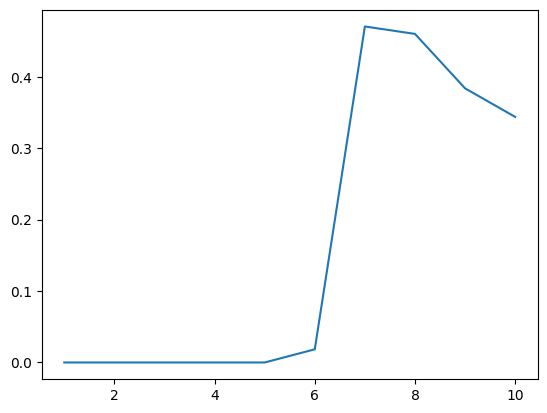

In [37]:
import numpy as np 

plt.plot(np.arange(1,11),hidden_codes[:,2])